In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [5]:
# Criação do Grafo
# nx.Graph() - não direcionado (mão dupla)
# nx.DiGraph() - direcionado (mão única)
malha_rodoviaria = nx.Graph()

# Adicionar arestas om pesos (kms)
# A biblioteca cria os nodes automaticamente quando criamos as arestas
malha_rodoviaria.add_edges_from([
    ("São Paulo","Campinas",{"peso":90}),
    ("São Paulo","Rio de Janeiro",{"peso":400}),
    ("Campinas","Ribeirão Preto",{"peso":220}),
    ("Campinas","Belo Horizonte",{"peso":500}),
    ("Rio de Janeiro","Belo Horizonte",{"peso":430}),
    ("Ribeirão Preto","Belo Horizonte",{"peso":320})
])

In [7]:
# Percursos
# Busca em largura (BFS)
bfs_arestas = list(nx.bfs_edges(malha_rodoviaria, source="São Paulo"))
print(f"Ordem de descoberta BFS a partir de SP:{bfs_arestas}")

Ordem de descoberta BFS a partir de SP:[('São Paulo', 'Campinas'), ('São Paulo', 'Rio de Janeiro'), ('Campinas', 'Ribeirão Preto'), ('Campinas', 'Belo Horizonte')]


In [9]:
# Componentes conexos (verifica isolados da rede)
isolados = list(nx.connected_components(malha_rodoviaria))
print(f"Componentes conexos (Ilhas de Redes): {isolados}")

Componentes conexos (Ilhas de Redes): [{'Belo Horizonte', 'Ribeirão Preto', 'Campinas', 'São Paulo', 'Rio de Janeiro'}]


In [10]:
# Grafos Ponderados e caminho mínimo
origem = "São Paulo"
destino = "Belo Horizonte"

print("--- ROTEAMENTO INTELIGENTE ---")

# Caminho mais curto ignorando o peso (menos cidades) BFS Puro
caminho_bfs = nx.shortest_path(malha_rodoviaria, source=origem, target=destino)
print(f"Rota com menos paradas (ignorando kms): {caminho_bfs}")

--- ROTEAMENTO INTELIGENTE ---
Rota com menos paradas (ignorando kms): ['São Paulo', 'Campinas', 'Belo Horizonte']


In [15]:
# Camiho mais curto considerando peso em KM (Dijkstra)
caminho_dijkstra = nx.dijkstra_path(malha_rodoviaria,
                                    source=origem,
                                    target=destino)
distancia_total = nx.dijkstra_path_length(malha_rodoviaria,
                                          source=origem,
                                          target=destino,
                                          weight="peso")
print(f"Rota com menos km (Dijkstra): {caminho_dijkstra}")
print(f"Distância total (Dijkstra): {distancia_total} km")

Rota com menos km (Dijkstra): ['São Paulo', 'Campinas', 'Belo Horizonte']
Distância total (Dijkstra): 590 km


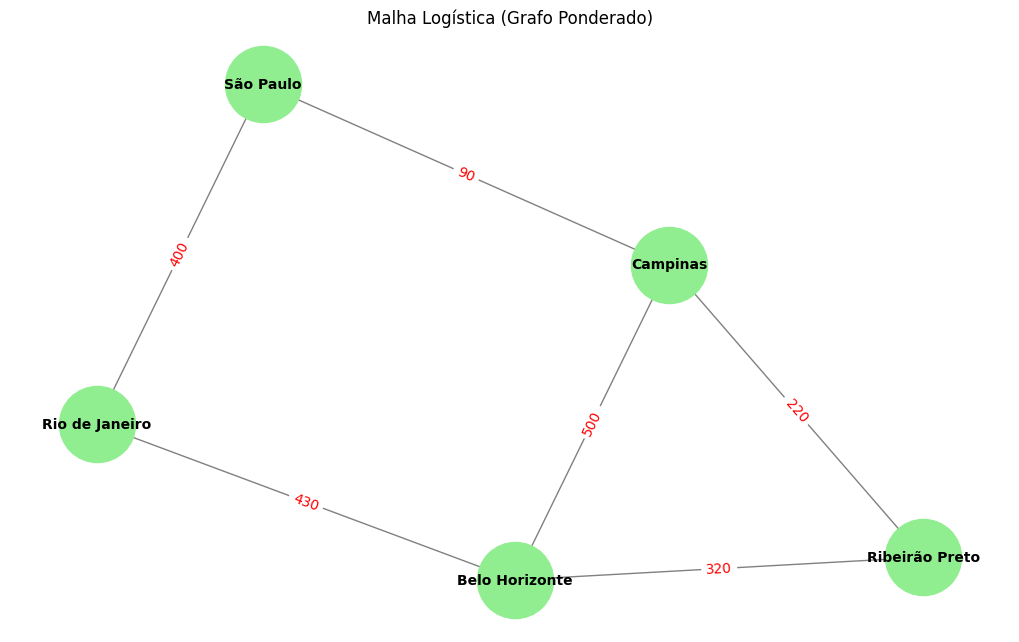

In [17]:
# Visualização com matplotlib
plt.figure(figsize=(10,6))
# spring layout simulafisica para afastar nos não conectados
# e aproximar os conectados
posicoes = nx.spring_layout(malha_rodoviaria, seed=42)
# Desenhando os nodes e arestas
nx.draw(malha_rodoviaria,
        posicoes,
        with_labels = True,
        node_color = "lightgreen",
        node_size = 3000,
        font_weight = "bold",
        font_size = 10,
        edge_color = "gray")
# Desenhando as etiquetas de peso (distancia em cima das linhas)
pesos = nx.get_edge_attributes(malha_rodoviaria, "peso")
nx.draw_networkx_edge_labels(malha_rodoviaria,
                             posicoes,
                             edge_labels=pesos,
                             font_color = "red")
plt.title("Malha Logística (Grafo Ponderado)")
plt.show()